# Fast convolution

So, the english is not very good, I will improve that

In [37]:
import itertools
from fractions import Fraction

import sympy as sy
import numpy as np
# for cyclic convolution
from scipy.ndimage import convolve1d

from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [38]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution
from cyclic_convolution import blahut

In [39]:
doc = fitz.open('Parhi - VLSI Digital Signal Processing Systems_ Design and Implementation-Wiley-Interscience (1999).pdf')

The base for this tutorial is the book "VLSI Digital Signal Processing Systems - Design and Implementation" of Keshab K. Parhi.

This tutorial not work with others vector sizes

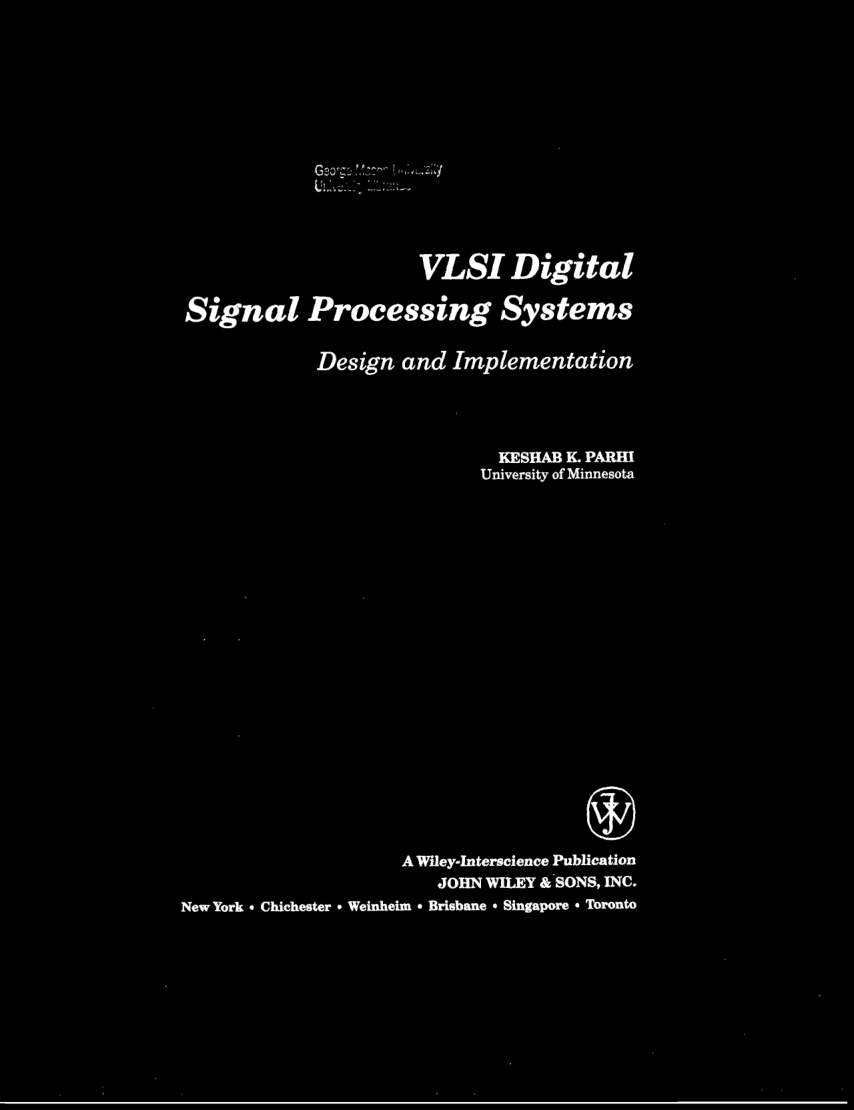

In [40]:
plot_pdf(doc[0], dpi=100)

## Polynomials

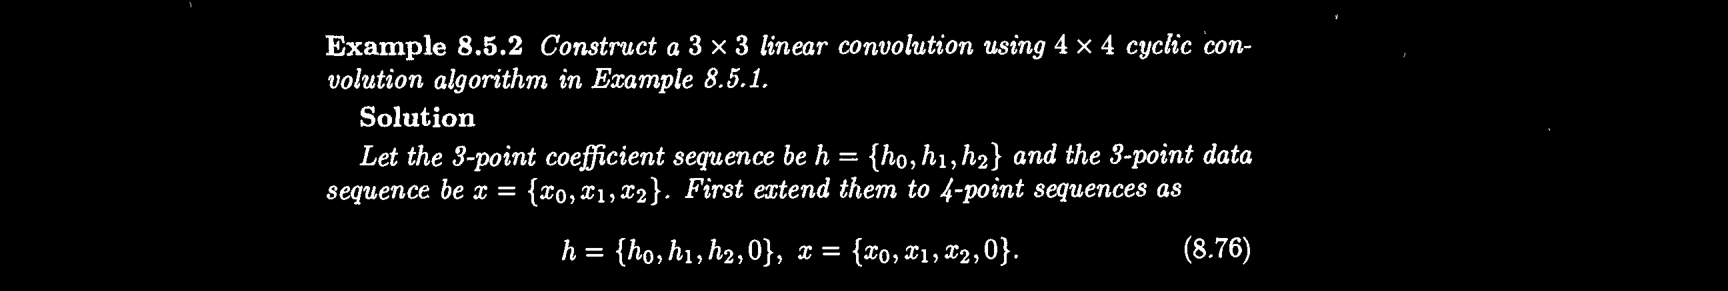

In [41]:
plot_pdf(doc[263], [.36, .49])

Size of vectors

In [42]:
d_num = 3
g_num = 3

In [43]:
n_cyclic = 4

Example of vectors for the convolution

In [44]:
d_values = list(range(1, d_num+1)) + [0] * (n_cyclic - d_num)
g_values = list(range(1, g_num+1)) + [0] * (n_cyclic - g_num)
print(d_values, g_values)

[1, 2, 3, 0] [1, 2, 3, 0]


Polynomial degree

In [45]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [46]:
x = sy.symbols("x")
x

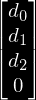

In [47]:
di = sy.Matrix(list(sy.symbols(" ".join(f"d_{i}"for i in range(d_num)))) + [0] * (n_cyclic - d_num))
di

In [48]:
sy.symbols(" ".join(f"d_{i}"for i in range(d_num)))

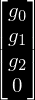

In [49]:
gi = sy.Matrix(list(sy.symbols(" ".join(f"g_{i}"for i in range(g_num)))) + [0] * (n_cyclic - g_num))
gi

In [50]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

In [51]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

In [52]:
sx = gx*dx
sx

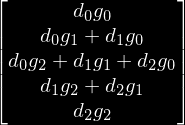

In [53]:
sy.Matrix(np.convolve(di.values(), gi.values()))

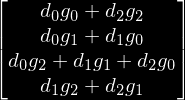

In [54]:
symmetrical_cyclic_convolution(di, gi)

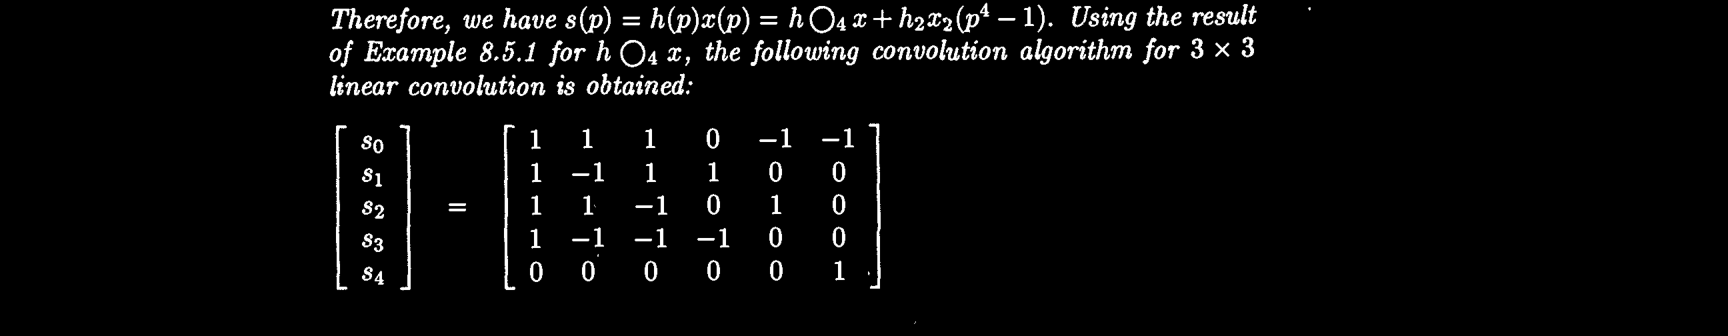

In [55]:
plot_pdf(doc[263], [.7, .85])

In [56]:
lst_c = [m + [n] for m, n in zip(blahut[n_cyclic]["c"], [-1] + [0] * (len(blahut[n_cyclic]["c"]) - 1))]
lst_c

In [57]:
lst_c2 = lst_c + [[0] * (len(lst_c[0]) - 1) + [1]]
lst_c2

In [58]:
len(lst_c2[-1])

In [59]:
len(blahut[n_cyclic]["c"][0])

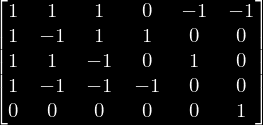

In [60]:
c_mtx = sy.Matrix(lst_c2)
c_mtx

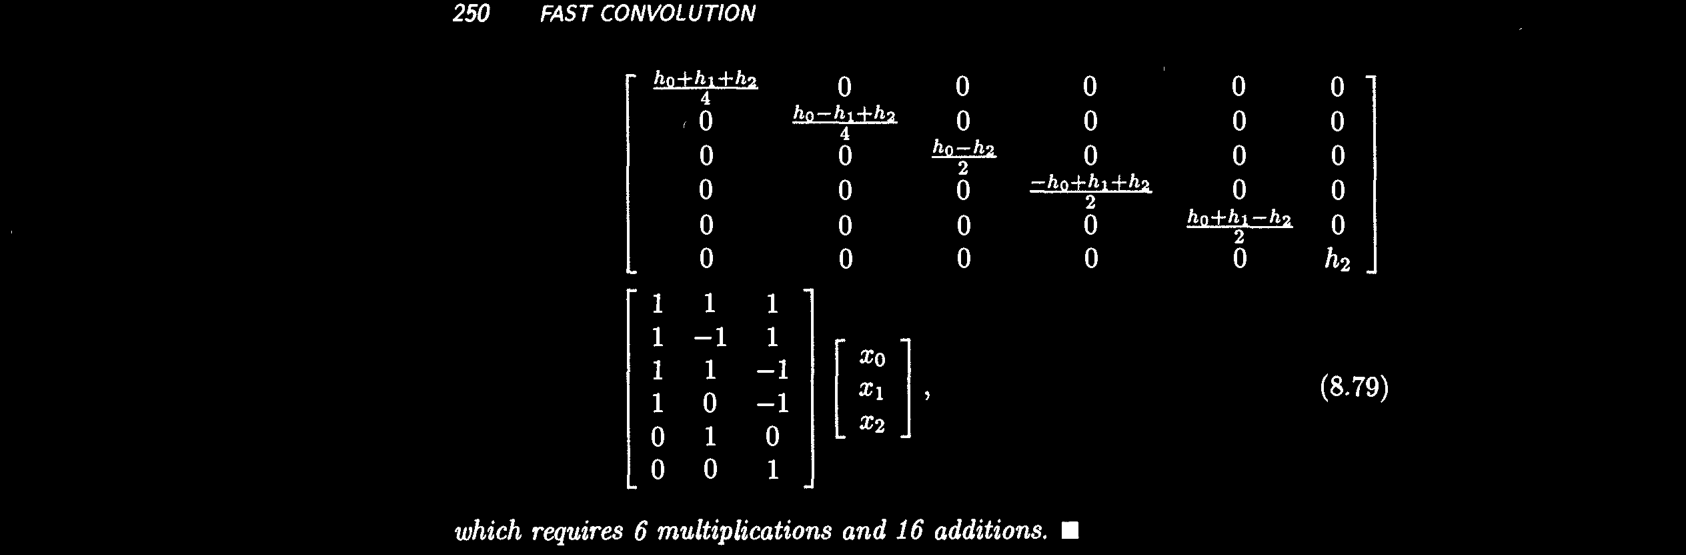

In [61]:
plot_pdf(doc[264], [.15, .4])

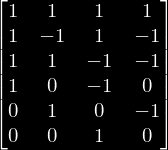

In [62]:
a_mtx = sy.Matrix(blahut[n_cyclic]["a"]  + [d_degree * [0] + [1] + [0] * (len(blahut[n_cyclic]["a"][0])-1-d_degree)])
a_mtx

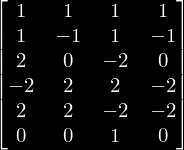

In [63]:
b_mtx = sy.Matrix(blahut[n_cyclic]["b"]  + [g_degree * [0] + [1] + [0] * (len(blahut[n_cyclic]["b"][0])-1-g_degree)])
b_mtx

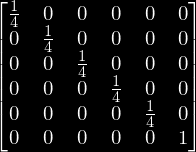

In [64]:
g_mtx = sy.diag(*([sy.Rational(*(blahut[n_cyclic]["gq"]))]*(max(b_mtx.shape)-1)), 1)
g_mtx

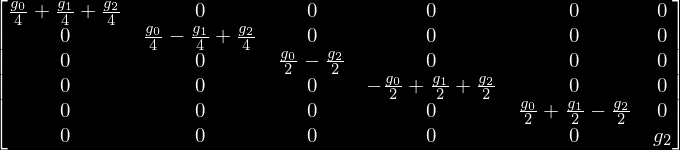

In [65]:
bg_mtx = sy.diag(*(g_mtx*b_mtx*gi).tolist())
bg_mtx

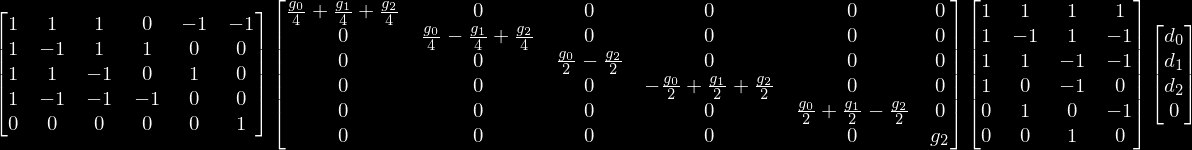

In [66]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s

## Example

In [67]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

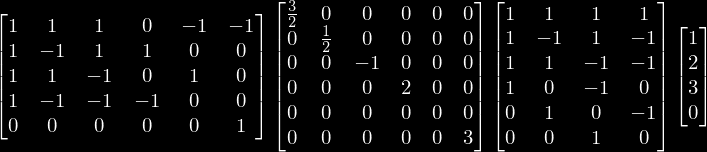

In [68]:
si = s.subs(subs)
si

In [69]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

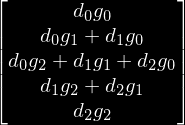

In [70]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)
se

Comparing numerical outputs from direct and winograd method

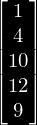

In [71]:
se.subs(subs)

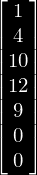

In [72]:
sy.Matrix(np.convolve(d_values, g_values))